# Loading Packages

In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.9/site-packa

In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


# Plotting Function

In [3]:
def plot(data, lam_cm, new_or_old = 'New', af_idx = 0):


    colours = ['C0', 'C1', 'C2', 'C3']
    title_list = ['160 $\mu$m', '1 mm', '1 cm', '10 cm']
    
    lw = 2.5
    
    # Make the figure 1 row, 4 columns
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))



    for a in axes.ravel():
        
        
        # In each plot loop over f_values to plot every f
        for i, f in enumerate(f_values):
            if a == axes[0]:
                a.plot(lam_cm, data[0][i], label = f'f = {f_values[i]}', color = colours[i], lw = lw)
                
            if a == axes[1]:
                a.plot(lam_cm, data[1][i], color = colours[i], lw = lw)
                
            if a == axes[2]:
                a.plot(lam_cm, data[2][i], color = colours[i], lw = lw, ls = 'dashdot')
                a.plot(lam_cm, data[3][i], color = colours[i], lw = lw, ls = ':')
                a.plot(lam_cm, data[4][i], color = colours[i], lw = lw, ls = '-')
            

        a.set_xscale('log')
        


        a.tick_params(
            which='major',
            direction='in',
            top=True,
            right=True,
            length=5,
            width=1.2,
            labelsize=16
        )

        
        a.set_xlabel("$\lambda$ (cm)", fontsize = 20)

        

    ax = axes[0]
    ax.set_title(rf"a$_{{\mathrm{{amax}}}}f$ = {title_list[af_idx]}", fontsize = 20)
    ax.legend(fontsize = 15, frameon = False)
    ax.set_ylim(1e-3, 1e3)
    ax.set_ylabel(r"$\kappa_{abs}$", fontsize = 20)
    ax.set_yscale('log')
    # axes[1].text(0.05, 0.95, f'{new_or_old}', transform=axes[1].transAxes, fontsize=20, va='top', ha='left')
    
    
    ax = axes[1]
    ax.set_ylim(1e-3, 1e3)
    ax.set_ylabel(r"$\kappa_{sca, eff}$", fontsize = 20)
    ax.set_yscale('log')
    
    axes[2].set_ylabel(r"$P \omega_{eff}, P, \omega_{eff}$", fontsize = 20)
    axes[2].set_yticks([0, 0.25, 0.5, 0.75, 1.0])

    plt.tight_layout()
    plt.show()
    
    return fig, axes

# Make Data

In [4]:
f_values = [1, 0.3, 0.1, 0.01]
n_f = len(f_values)

In [5]:
# Set the a_max * f column that we are calculating for, and the index (column number) for plottting
amax_times_f_cm = 1
af_idx = 2

In [6]:
# The minimum a in microns from Zhang 2023, convert to cm
a_min_micron = 0.1
a_min_cm = micron_to_cm(a_min_micron)

In [7]:
N = 100
lam_cm = np.logspace(-5, 1, N)

In [8]:
kappa_abs_ARRAY         = np.zeros((n_f, N))
kappa_sca_eff_ARRAY     = np.zeros((n_f, N))
P_ARRAY                 = np.zeros((n_f, N))
omega_eff_ARRAY         = np.zeros((n_f, N))
P_times_omega_eff_ARRAY = np.zeros((n_f, N))
x_ARRAY                 = np.zeros((n_f, N))


# Loop over the f values
for i, f in enumerate(f_values):
    # Define the a_max_grid based on f
    a_max_cm = amax_times_f_cm / f
    a_max_grid_cm = np.geomspace(a_min_cm, a_max_cm, N)
    
    
    x = (2 * np.pi * a_max_grid_cm) / lam_cm
    
    # Get the optical constants and density using DHSARP based on the porosity
    oc, rho_g_cm3 = do.get_dsharp_mix(porosity=1-f)
    mass_grams = calculate_grain_mass(a_max_grid_cm, rho_g_cm3, "cm")
    
    # Using extrapol=True, extrapolate_large_grains=True only manes a tiny difference 
    # (0.2603253774207066 max summing over N)
    res = do.get_opacities(a_max_grid_cm, lam_cm, rho_g_cm3, oc, extrapol=True, extrapolate_large_grains=True)
    
    
    k_abs = res["k_abs"]
    k_sca = res["k_sca"]
    g = res["g"]
    S1    = res['S1']
    S2    = res['S2']
    theta = res['theta']
    


    # MRN mass weighting (q = 3.5)
    distri = a_max_grid_cm**0.5
    distri[a_max_grid_cm > a_max_cm] = 0
    distri /= distri.sum()

    # Size-averaged opacities
    kabs_avg = np.sum(k_abs * distri[:, None], axis=0)
    ksca_avg = np.sum(k_sca * distri[:, None], axis=0)
    g_avg = np.sum(g * k_sca * distri[:, None], axis=0) / ksca_avg

    # Effective scattering opacity
    ksca_eff = (1 - g_avg) * ksca_avg

    # Effective albedo
    omega = ksca_avg / (kabs_avg + ksca_avg)
    omega_eff = ksca_eff / (kabs_avg + ksca_eff)

    zscat = do.calculate_mueller_matrix(lam_cm, mass_grams, 
                                        res['S1'], res['S2'], 
                                        theta=res['theta'], 
                                        k_sca=res['k_sca'])['zscat']

    i90 = np.argmin(np.abs(theta-90))
    
    
    # Polarization degree
    Z11eff = np.sum(zscat[:, :, i90, 0] * distri[:, None], 0)
    Z12eff = np.sum(zscat[:, :, i90, 1] * distri[:, None], 0)

    P = np.abs(Z12eff / Z11eff)

    # Product
    P_times_omega_eff_ARRAY[i] = P * omega_eff
    
    
    # Save to the arrays
    kappa_abs_ARRAY[i]         = kabs_avg
    kappa_sca_eff_ARRAY[i]     = ksca_eff
    P_ARRAY[i]                 = P
    omega_eff_ARRAY[i]         = omega_eff
    P_times_omega_eff_ARRAY[i] = P * omega_eff
    x_ARRAY[i]                 = x
        
        
data_old = [kappa_abs_ARRAY, kappa_sca_eff_ARRAY, P_ARRAY, omega_eff_ARRAY, P_times_omega_eff_ARRAY]

Please cite Warren & Brandt (2008) when using these optical constants
Please cite Draine 2003 when using these optical constants
Reading opacities from troilitek
Please cite Henning & Stognienko (1996) when using these optical constants
Reading opacities from organicsk
Please cite Henning & Stognienko (1996) when using these optical constants
| material                            | volume fractions | mass fractions |
|-------------------------------------|------------------|----------------|
| Water Ice (Warren & Brandt 2008)    | 0.3642           | 0.2            |
| Astronomical Silicates (Draine 2003)| 0.167            | 0.329          |
| Troilite (Henning)                  | 0.02578          | 0.07434        |
| Organics (Henning)                  | 0.443            | 0.3966         |
Mie ... Done!
Please cite Warren & Brandt (2008) when using these optical constants
Please cite Draine 2003 when using these optical constants
Reading opacities from troilitek
Please cite Henning & S

/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 1e+11%: above error tolerance
  warnings.warn(


Mie ... Done!
Please cite Warren & Brandt (2008) when using these optical constants
Please cite Draine 2003 when using these optical constants
Reading opacities from troilitek
Please cite Henning & Stognienko (1996) when using these optical constants
Reading opacities from organicsk
Please cite Henning & Stognienko (1996) when using these optical constants
| material                            | volume fractions | mass fractions |
|-------------------------------------|------------------|----------------|
| Water Ice (Warren & Brandt 2008)    | 0.3642           | 0.2            |
| Astronomical Silicates (Draine 2003)| 0.167            | 0.329          |
| Troilite (Henning)                  | 0.02578          | 0.07434        |
| Organics (Henning)                  | 0.443            | 0.3966         |
using Maxwell-Garnett mixing: first component should be host material (= matrix)
    matrix = Vacuum
Mie ... 1 %

/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 2.1e+11%: above error tolerance
  warnings.warn(


Mie ... Done!
Please cite Warren & Brandt (2008) when using these optical constants
Please cite Draine 2003 when using these optical constants
Reading opacities from troilitek
Please cite Henning & Stognienko (1996) when using these optical constants
Reading opacities from organicsk
Please cite Henning & Stognienko (1996) when using these optical constants
| material                            | volume fractions | mass fractions |
|-------------------------------------|------------------|----------------|
| Water Ice (Warren & Brandt 2008)    | 0.3642           | 0.2            |
| Astronomical Silicates (Draine 2003)| 0.167            | 0.329          |
| Troilite (Henning)                  | 0.02578          | 0.07434        |
| Organics (Henning)                  | 0.443            | 0.3966         |
using Maxwell-Garnett mixing: first component should be host material (= matrix)
    matrix = Vacuum
Mie ... 1 %

/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 2.7e+11%: above error tolerance
  warnings.warn(


Mie ... Done!


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 2.8e+11%: above error tolerance
  warnings.warn(


In [9]:
# kappa_abs_ARRAY         = np.zeros((n_f, N))
# kappa_sca_eff_ARRAY     = np.zeros((n_f, N))
# P_ARRAY                 = np.zeros((n_f, N))
# omega_eff_ARRAY         = np.zeros((n_f, N))
# P_times_omega_eff_ARRAY = np.zeros((n_f, N))
# x_ARRAY                 = np.zeros((n_f, N))


# # Loop over the f values
# for i, f in enumerate(f_values):
#     # Define the a_max_grid based on f
#     a_max_cm = amax_times_f_cm / f
#     a_max_grid_cm = np.geomspace(a_min_cm, a_max_cm, N)
    
    
#     x = (2 * np.pi * a_max_grid_cm) / lam_cm
    
#     # Get the optical constants and density using DHSARP based on the porosity
#     oc, rho_g_cm3 = do.get_dsharp_mix(porosity=1-f, rule='Bruggeman')
#     mass_grams = calculate_grain_mass(a_max_grid_cm, rho_g_cm3, "cm")
    
#     res = do.get_opacities(a_max_grid_cm, lam_cm, rho_g_cm3, oc, extrapol=True, extrapolate_large_grains=True, n_angle=100)
    
    
#     k_abs = res["k_abs"]
#     k_sca = res["k_sca"]
#     g = res["g"]
#     S1    = res['S1']
#     S2    = res['S2']
#     theta = res['theta']
    


#     # MRN mass weighting (q = 3.5)
#     distri = a_max_grid_cm**0.5
#     distri[a_max_grid_cm > a_max_cm] = 0
#     distri /= distri.sum()

#     # Size-averaged opacities
#     kabs_avg = np.sum(k_abs * distri[:, None], axis=0)
#     ksca_avg = np.sum(k_sca * distri[:, None], axis=0)
#     g_avg = np.sum(g * k_sca * distri[:, None], axis=0) / ksca_avg

#     # Effective scattering opacity
#     ksca_eff = (1 - g_avg) * ksca_avg

#     # Effective albedo
#     omega = ksca_avg / (kabs_avg + ksca_avg)
#     omega_eff = ksca_eff / (kabs_avg + ksca_eff)

#     zscat = do.calculate_mueller_matrix(lam_cm, mass_grams, 
#                                         res['S1'], res['S2'], 
#                                         theta=res['theta'], 
#                                         k_sca=res['k_sca'])['zscat']

#     i90 = np.argmin(np.abs(theta-90))
    
    
#     # Polarization degree
#     #Z11 = zscat[:, :, i90, 0]
#     #Z12 = zscat[:, :, i90, 1]

    
#     Z11eff = np.sum(zscat[:, :, i90, 0] * distri[:, None], 0)
#     Z12eff = np.sum(zscat[:, :, i90, 1] * distri[:, None], 0)

#     P = np.abs(Z12eff / Z11eff)

#     # Product
#     P_times_omega_eff_ARRAY[i] = P * omega_eff
    
    
#     # Save to the arrays
#     kappa_abs_ARRAY[i]         = kabs_avg
#     kappa_sca_eff_ARRAY[i]     = ksca_eff
#     P_ARRAY[i]                 = P
#     omega_eff_ARRAY[i]         = omega_eff
#     P_times_omega_eff_ARRAY[i] = P * omega_eff
#     x_ARRAY[i]                 = x
        
        
# data_new = [kappa_abs_ARRAY, kappa_sca_eff_ARRAY, P_ARRAY, omega_eff_ARRAY, P_times_omega_eff_ARRAY]

# Plot

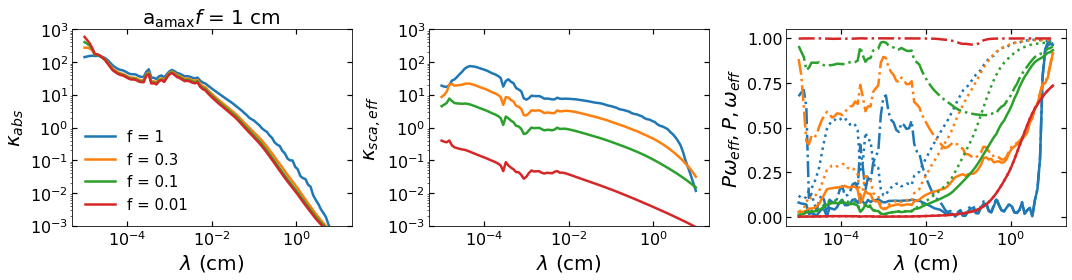

NameError: name 'data_new' is not defined

In [10]:
fig, axes = plot(data_old, lam_cm, new_or_old = 'Old', af_idx = 2)




fig, axes = plot(data_new, lam_cm, new_or_old = 'New', af_idx = 2)

i = 0 

var = ['k_abs', 'k_sca, eff', 'P', 'omega_eff', 'P*omega_eff']
for j in range(len(data_new)):
    
    diff = np.abs(data_old[j] - data_new[j])
    diff_sum = np.sum(diff)
    
    print(f'{var[j]} diff = {diff_sum}')